# Дерево решений в задаче регрессии

## 1. Загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (11, 6)
RANDOM_STATE = 42

from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()
print("\nРазмер датасета:", df.shape)


Размер датасета: (20640, 9)


In [2]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Первичный анализ

### 2a. Проверка и удаление пропусков

In [3]:
print('Пропуски по столбцам:')
print(df.isnull().sum())

n_before = len(df)
df = df.dropna().reset_index(drop=True)
print(f'\nУдалено строк с пропусками: {n_before - len(df)}')
print('Осталось строк:', len(df))

Пропуски по столбцам:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Удалено строк с пропусками: 0
Осталось строк: 20640


In [4]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


### 2b. Нормализация одного признака

In [5]:
scaler = StandardScaler()
df['MedInc'] = scaler.fit_transform(df[['MedInc']])

print('MedInc после нормализации:')
print(f'  среднее = {df["MedInc"].mean():.4f}  (≈ 0)')
print(f'  std     = {df["MedInc"].std():.4f}  (≈ 1)')
df[['MedInc']].describe().round(3).T

MedInc после нормализации:
  среднее = 0.0000  (≈ 0)
  std     = 1.0000  (≈ 1)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,0.0,1.0,-1.774,-0.688,-0.177,0.459,5.858


## 3. Разделение на обучающее и тестовое множества (80/20)

In [6]:
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print('Обучающая выборка:', X_train.shape)
print('Тестовая выборка: ', X_test.shape)

Обучающая выборка: (16512, 8)
Тестовая выборка:  (4128, 8)


## 4–5. Линейная регрессия

In [7]:
lin_reg = LinearRegression().fit(X_train, y_train)

lin_train_score = lin_reg.score(X_train, y_train)
lin_test_score = lin_reg.score(X_test, y_test)

print('Линейная регрессия')
print(f'  R2 на обучении: {lin_train_score:.4f}')
print(f'  R2 на тесте:    {lin_test_score:.4f}')

Линейная регрессия
  R2 на обучении: 0.6126
  R2 на тесте:    0.5758


Линейная регрессия объясняет ~58% дисперсии на тесте. Это базовый уровень для сравнения с деревом.

## 6. Дерево решений

### Обучение дерева с параметрами по умолчанию

In [8]:
tree_default = DecisionTreeRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)

print('Дерево решений (параметры по умолчанию)')
print(f'  R2 на обучении: {tree_default.score(X_train, y_train):.4f}')
print(f'  R2 на тесте:    {tree_default.score(X_test, y_test):.4f}')

Дерево решений (параметры по умолчанию)
  R2 на обучении: 1.0000
  R2 на тесте:    0.6228


### 6b. Визуализация части дерева

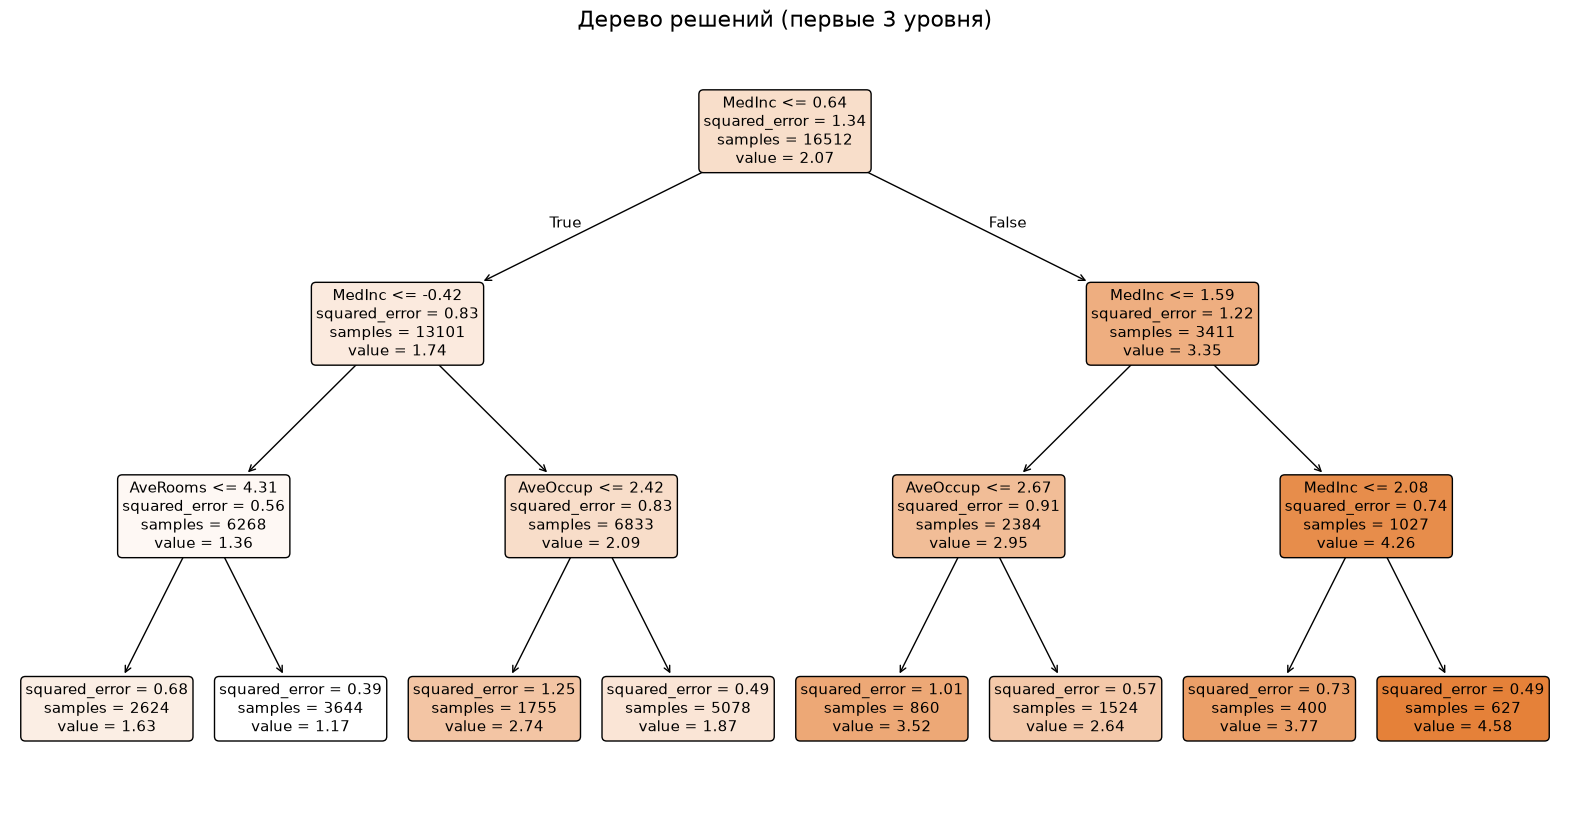

In [9]:
tree_viz = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(tree_viz,
          feature_names=list(X.columns),
          filled=True, rounded=True, precision=2, fontsize=11)
plt.title('Дерево решений (первые 3 уровня)', fontsize=16)
plt.show()

В корне дерева — признак `MedInc` (доход): именно он даёт наибольшее снижение ошибки, что согласуется с его сильнейшей корреляцией с ценой.

## 7. Оптимизация гиперпараметров дерева

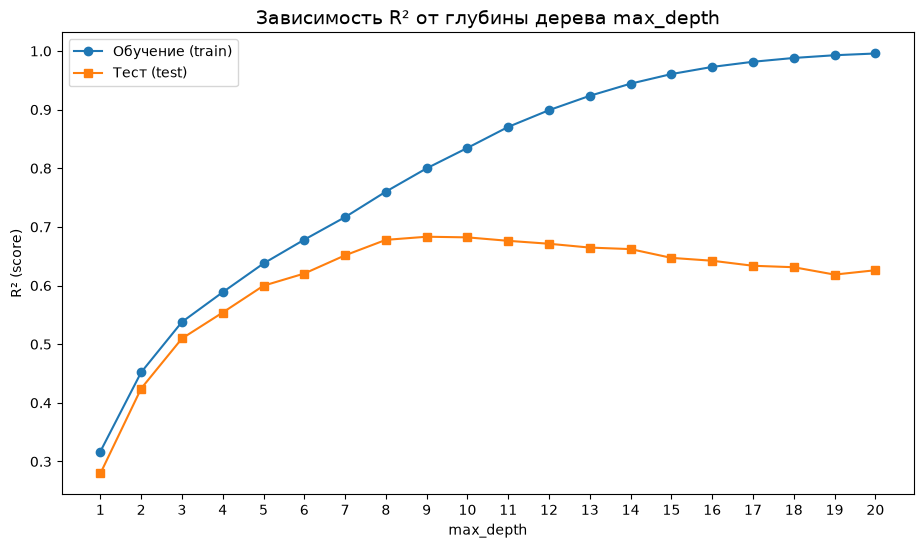

In [10]:
depths = range(1, 21)
train_scores, test_scores = [], []
for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    train_scores.append(m.score(X_train, y_train))
    test_scores.append(m.score(X_test, y_test))

plt.figure(figsize=(11, 6))
plt.plot(list(depths), train_scores, marker='o', label='Обучение (train)')
plt.plot(list(depths), test_scores, marker='s', label='Тест (test)')
plt.title('Зависимость R² от глубины дерева max_depth', fontsize=14)
plt.xlabel('max_depth')
plt.ylabel('R² (score)')
plt.xticks(list(depths))
plt.legend()
plt.show()

На графике видно расхождение кривых: с ростом глубины train-R² стремится к 1, а test-R² сначала растёт, достигает максимума (~глубина 10), затем падает — это зона переобучения.

In [11]:
param_grid = {
    'max_depth': [6, 8, 10, 12, 14],
    'min_samples_leaf': [1, 5, 10, 20, 50],
}
grid = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                    param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
print('Лучшие параметры:', grid.best_params_)
print(f'Лучший R2 на кросс-валидации: {grid.best_score_:.4f}')
print(f'\nОптимизированное дерево')
print(f'  R2 на обучении: {best_tree.score(X_train, y_train):.4f}')
print(f'  R2 на тесте:    {best_tree.score(X_test, y_test):.4f}')

Лучшие параметры: {'max_depth': 12, 'min_samples_leaf': 20}
Лучший R2 на кросс-валидации: 0.7251

Оптимизированное дерево
  R2 на обучении: 0.8037
  R2 на тесте:    0.7244


## 8. Выводы

In [12]:
summary = pd.DataFrame([
    {'Модель': 'Линейная регрессия',
     'R2 train': round(lin_train_score, 4),
     'R2 test (score)': round(lin_test_score, 4)},
    {'Модель': 'Дерево решений (по умолчанию)',
     'R2 train': round(tree_default.score(X_train, y_train), 4),
     'R2 test (score)': round(tree_default.score(X_test, y_test), 4)},
    {'Модель': 'Дерево решений (оптимизированное)',
     'R2 train': round(best_tree.score(X_train, y_train), 4),
     'R2 test (score)': round(best_tree.score(X_test, y_test), 4)},
])
summary

,Модель,R2 train,R2 test (score)
0,Линейная регрессия,0.6126,0.5758
1,Дерево решений (по умолчанию),1.0000,0.6228
2,Дерево решений (оптимизированное),0.8037,0.7244


### a) Сравнение точности моделей
- **Линейная регрессия** и **дерево по умолчанию** дают близкую точность на тесте (~0.58), но дерево без ограничений сильно переобучено (R²=1.0 на обучении).
- **Оптимизация** `max_depth` и `min_samples_leaf` подняла точность дерева до **R² ≈ 0.72** — заметно лучше линейной регрессии. Прирост объясняется тем, что дерево улавливает **нелинейные зависимости** (в первую очередь географию: цена жилья резко меняется у побережья), недоступные линейной модели.

### b) Для каких задач какая модель предпочтительнее

**Линейная регрессия**
- Плюсы: простая, быстрая, интерпретируемая (коэффициенты показывают вклад признаков), устойчива к переобучению, хорошо работает при линейных зависимостях.
- Минусы: не улавливает нелинейности и взаимодействия признаков; чувствительна к выбросам и мультиколлинеарности.
- Когда использовать: когда связь между признаками и целью близка к линейной, важна интерпретируемость и скорость, данных немного.

**Дерево решений**
- Плюсы: моделирует сложные нелинейные зависимости и взаимодействия; не требует масштабирования; наглядно интерпретируется на малой глубине; работает со смешанными типами признаков.
- Минусы: легко переобучается без регуляризации; неустойчиво (небольшое изменение данных меняет структуру); предсказания «ступенчатые», плохо экстраполирует за пределы обучающих данных.
- Когда использовать: когда зависимости нелинейны и есть взаимодействия признаков; как база для ансамблей (случайный лес, градиентный бустинг), которые устраняют главный минус одиночного дерева — неустойчивость.

**Итог.** На данных о недвижимости Калифорнии оптимизированное дерево решений точнее линейной регрессии (R² 0.71 против 0.59), поскольку зависимость цены от признаков (особенно географии) существенно нелинейна.